<a href="https://colab.research.google.com/github/AlvinR21/Northstar-analysis/blob/main/R_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
install.packages("ggplot2")
install.packages("dplyr")

library(ggplot2)
library(dplyr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [4]:
customers <- read.csv("customers_clean.csv")
drivers <- read.csv("drivers_clean.csv")
vehicles <- read.csv("vehicles_clean.csv")
hubs <- read.csv("hubs_clean.csv")
orders <- read.csv("orders_clean.csv")
deliveries <- read.csv("deliveries_clean.csv")
incidents <- read.csv("incidents_clean.csv")
complaints <- read.csv("complaints_clean.csv")
app_events <- read.csv("app_events_clean.csv")

In [5]:
#To calculate the late rate per hub using dplyr
hub_late_rate <- deliveries %>%
  group_by(hub_id) %>%
  summarise(
    total = n(),
    late = sum(is_late == "True"),
    late_rate = late / total
  )

  print(hub_late_rate)

# A tibble: 8 × 4
  hub_id total  late late_rate
  <chr>  <int> <int>     <dbl>
1 H01      136    58     0.426
2 H02      106    44     0.415
3 H03      119    49     0.412
4 H04      127    60     0.472
5 H05      115    59     0.513
6 H06      104    59     0.567
7 H07      115    46     0.4  
8 H08      128    60     0.469


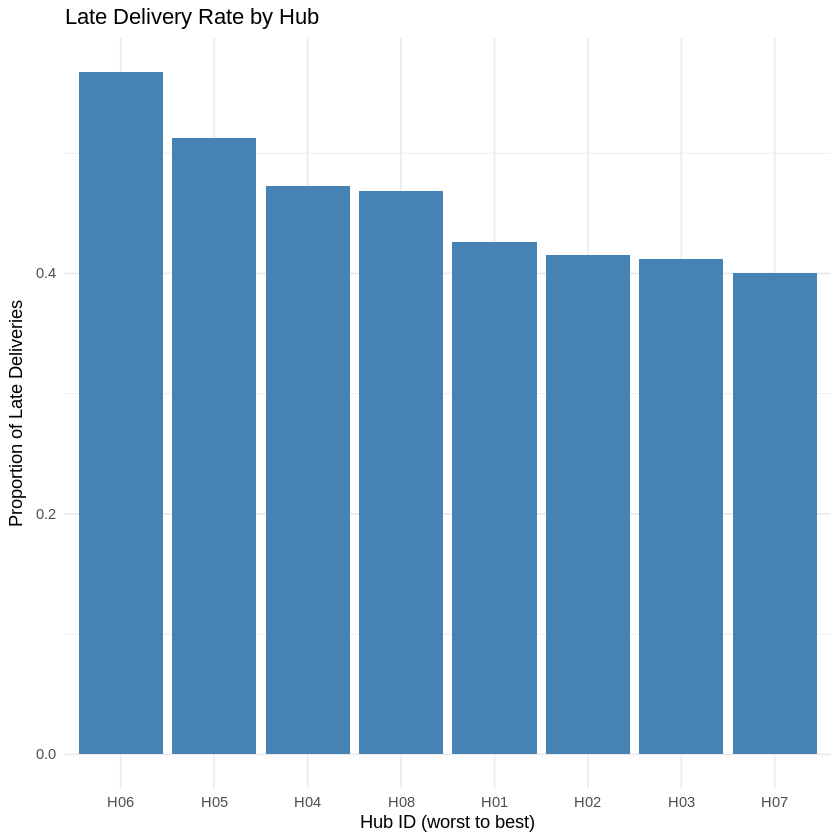

In [6]:
#Build the bar chart with ggplot
ggplot(hub_late_rate, aes(x = reorder(hub_id, -late_rate), y = late_rate)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  labs(
    title = "Late Delivery Rate by Hub",
    x = "Hub ID (worst to best)",
    y = "Proportion of Late Deliveries"
  ) +
  theme_minimal()

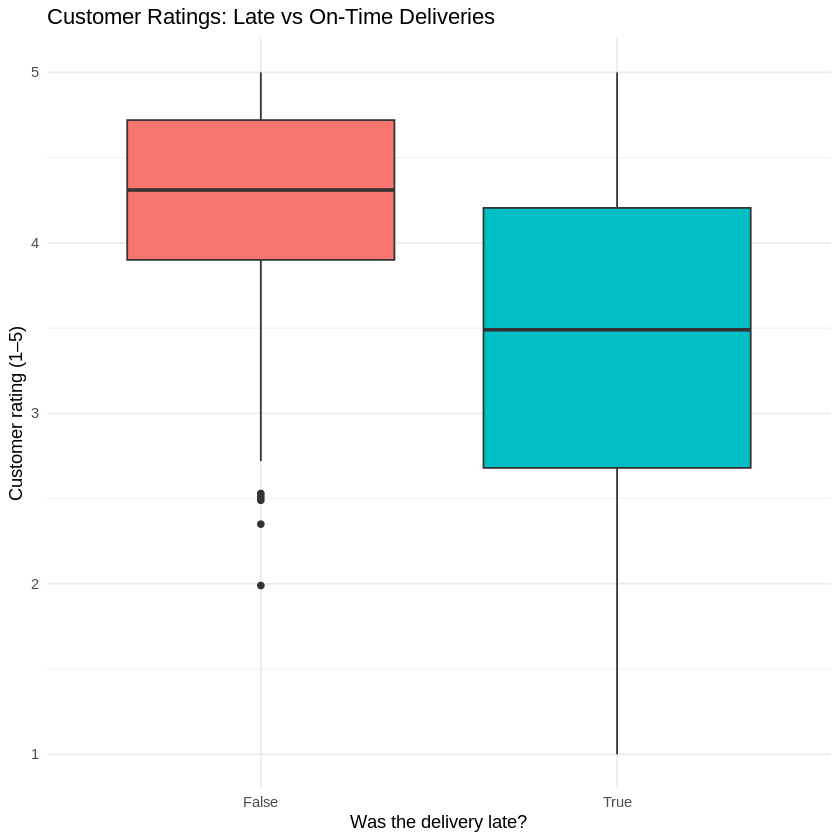

In [7]:

#Filter out rows where customer rating is missing
ratings_data <- deliveries %>%
  filter(!is.na(customer_rating_post_delivery))
#Build a boxplot comparing ratings for late vs on-time deliveries
ggplot(ratings_data, aes(x = is_late, y = customer_rating_post_delivery, fill = is_late)) +
  geom_boxplot() +
  labs(
    title = "Customer Ratings: Late vs On-Time Deliveries",
    x = "Was the delivery late?",
    y = "Customer rating (1–5)"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

The average rating for on-time deliveries is 4.5, and the average rating for late deliveries is 3.5. A drop of 1 point on a 5-point scale (20% of the rating scale). There is a direct link between operational lateness and unhappy customers.

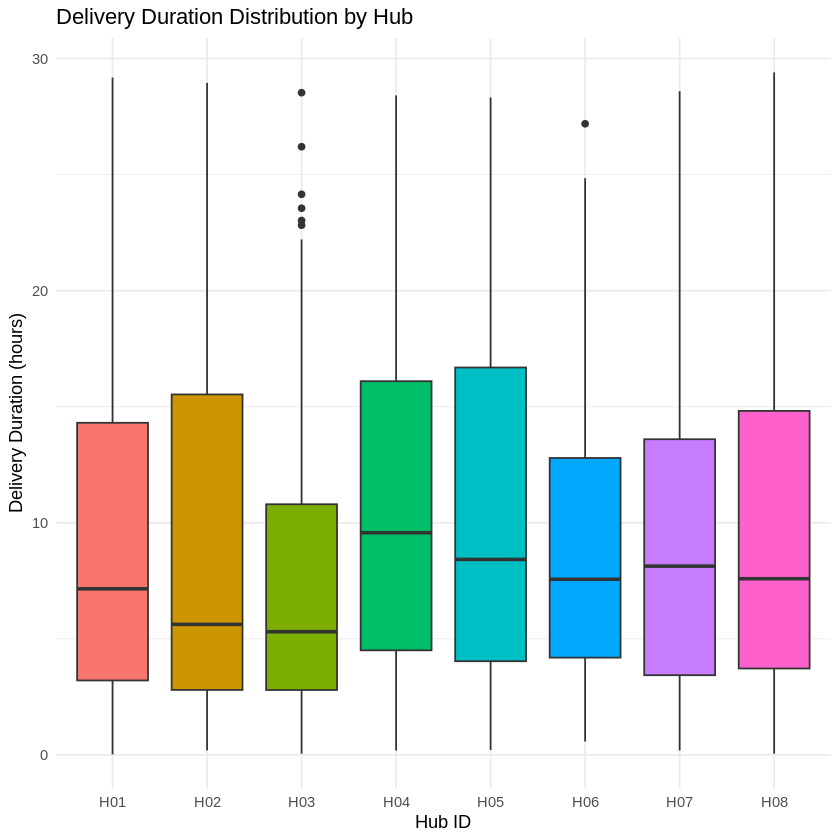

In [8]:
#Filter out the impossible negative durations and the long tail
duration_data <- deliveries %>%
  filter(delivery_duration_hours > 0 & delivery_duration_hours < 30)

#Boxplot of duration per hub
ggplot(duration_data, aes(x = hub_id, y = delivery_duration_hours, fill = hub_id)) +
  geom_boxplot() +
  labs(
    title = "Delivery Duration Distribution by Hub",
    x = "Hub ID",
    y = "Delivery Duration (hours)"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

Decision 6:the duration plot is limited to 30 hours. The left out delivery durations longer than 30 hours because they were too far off the chart and would have messed it up. The number of excluded items is small compared to the dataset, and the visualised summaries still show what normal operations look like.

H04 has the longest median delivery time, while H03 has the most extreme outliers. Based on the earlier finding that H06 has the highest late-rate, three different hubs are "worst" depending on the metric. There is no one fix that will work for all of NorthStar's hubs' performance problems; each hub needs its own operational fix.



# A tibble: 7 × 2
  home_zone complaint_count
  <chr>               <int>
1 North                  64
2 Central                56
3 South                  50
4 Riverside              45
5 East                   40
6 Airport                34
7 West                   31


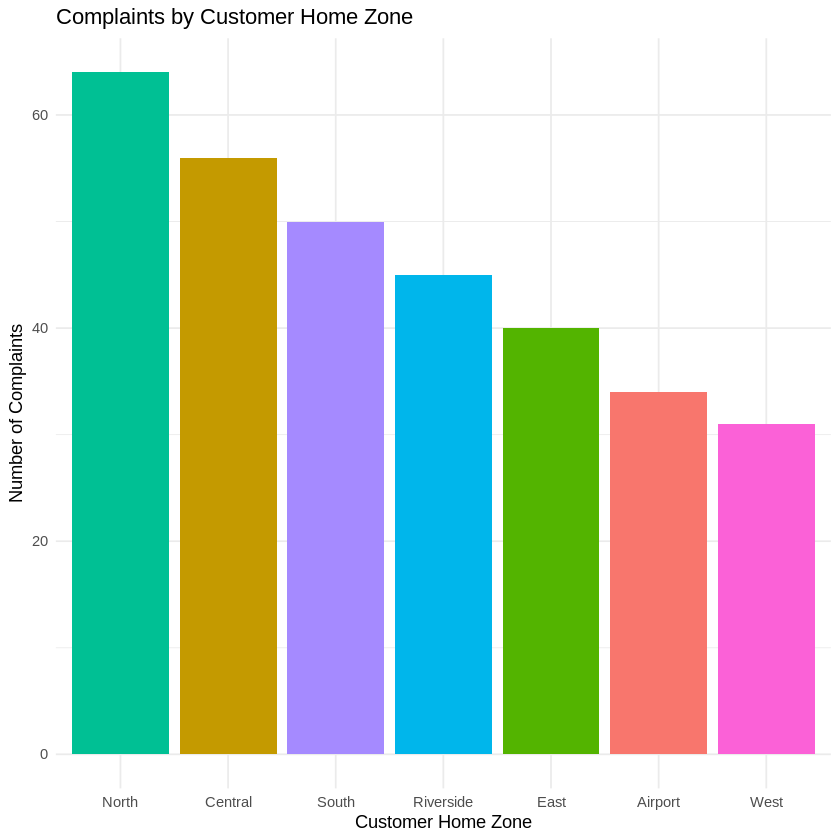

In [11]:
#Count the complaint_count by home_zone
complaints_by_zone <- complaints %>%
  inner_join(customers, by = "customer_id") %>%
  group_by(home_zone) %>%
  summarise(complaint_count = n()) %>%
  arrange(desc(complaint_count))

print(complaints_by_zone)

#Create a bar chart using ggplot
ggplot(complaints_by_zone, aes(x = reorder(home_zone, -complaint_count), y = complaint_count, fill = home_zone)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Complaints by Customer Home Zone",
    x = "Customer Home Zone",
    y = "Number of Complaints"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

The North zone has the most complaints (64), followed by the Central zone (56). The airport zone, which has the worst hub (H06), has the second-fewest complaints (34). So, the gap between operational failure (H06/Airport) and customer complaints (North/Central) is even bigger than we first thought. This supports the case study's claim that NorthStar lacks an integrated operational view.

In [10]:
customers$home_zone[customers$home_zone == "Ctr"] <- "Central"


Decision 7:finding and fixing the Ctr value in customers late in the process. During the R analytics phase, the value Ctr was still present in customers home_zone even after the first cleaning step. Boolean indexing was used to fix this in R. This incident shows a common problem in real-world data engineering: cleaning steps done in one tool may not work well in a multi-stage pipeline. In the future, there should be automated validation checks at every stage to find these kinds of problems sooner.

In [13]:
#Build a small data frame of operational metrics for relation analysis
delivery_metrics <- deliveries %>%
  filter(!is.na(customer_rating_post_delivery)) %>%
  filter(delivery_duration_hours > 0) %>%
  select(
    delivery_duration_hours,
    manual_route_override_count,
    customer_rating_post_delivery,
    fuel_or_charge_cost,
    route_distance_km
  )

  #Calculate relation between every paris of variable
  correlation_matrix <- cor(delivery_metrics)

  round(correlation_matrix, 2)

,delivery_duration_hours,manual_route_override_count,customer_rating_post_delivery,fuel_or_charge_cost,route_distance_km
delivery_duration_hours,1.00,-0.02,-0.30,0.05,0.02
manual_route_override_count,-0.02,1.00,-0.06,0.10,0.20
customer_rating_post_delivery,-0.30,-0.06,1.00,-0.07,0.02
fuel_or_charge_cost,0.05,0.10,-0.07,1.00,0.53
route_distance_km,0.02,0.20,0.02,0.53,1.00


The relationship between manual_route_override_count and customer_rating_post_delivery is 0.06, which is very close to zero. Three independent analyses, show that overrides do NOT affect performance outcomes. The hypothesis regarding overrides in the case study should be regarded as disproven.